<a href="https://colab.research.google.com/github/Whity2004/cloud-computing-website/blob/main/ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# --- STEP 1: CONNECT TO GOOGLE DRIVE AND LOAD DATA ---
# Instructions: Copy this entire cell, paste it into Colab, and run it.

from google.colab import drive
import pandas as pd
import os

# 1. Mount Google Drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Define the path to your dataset
# Make sure you created a folder named 'ProjectData' in your Drive
# and uploaded the CSV file there.
file_path = '/content/drive/MyDrive/ProjectData/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# 3. Check if file exists and load it
if os.path.exists(file_path):
    print("File found! Loading dataset...")
    df = pd.read_csv(file_path)
    print("Dataset Loaded Successfully!")

    # 4. Display the first 5 rows
    print("\nDisplaying first 5 rows of the dataset:")
    display(df.head())
else:
    print(f"Error: File not found at {file_path}")
    print("Please ensure you have uploaded 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv' to a folder named 'ProjectData' in your Google Drive.")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found! Loading dataset...
Dataset Loaded Successfully!

Displaying first 5 rows of the dataset:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# --- STEP 2: PRE-TEST OF THE EXISTING SYSTEM ---
# This script simulates a traditional signature-based NIDS.
# Copy this into a NEW cell in Colab and run it.

import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

print("Running Pre-test (Traditional System Simulation)...")

# 1. Prepare a test copy of the data
# We strip spaces from columns to ensure the rules find the right data
temp_df = df.copy()
temp_df.columns = temp_df.columns.str.strip()

# 2. Define the 'Ground Truth'
# We convert the real labels to binary: 0 for BENIGN, 1 for any Attack
y_true = temp_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# 3. Apply Traditional Signature Rules (The 'Existing System')
# Rule A: If flow duration is extremely short (< 10), flag as possible attack
# Rule B: If packet count is over a fixed old-school threshold (> 50)
temp_df['Signature_Prediction'] = 0
temp_df.loc[(temp_df['Flow Duration'] < 10) | (temp_df['Total Fwd Packets'] > 50), 'Signature_Prediction'] = 1

y_pred_signature = temp_df['Signature_Prediction']

# 4. Calculate Results
acc = accuracy_score(y_true, y_pred_signature)
rec = recall_score(y_true, y_pred_signature, zero_division=0)
f1 = f1_score(y_true, y_pred_signature, zero_division=0)

print("\n" + "="*30)
print("EXISTING SYSTEM PRE-TEST RESULTS")
print("="*30)
print(f"Accuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f} (This shows how many attacks were caught)")
print(f"F1-Score:  {f1:.4f}")
print("="*30)

print("\nANALYSIS:")
if rec < 0.60:
    print("The pre-test confirms the problem: The traditional system has a low Recall.")
    print("It is missing many modern attack patterns because its rules are too rigid.")
else:
    print("The traditional system caught some attacks, but ML will improve precision.")



Running Pre-test (Traditional System Simulation)...

EXISTING SYSTEM PRE-TEST RESULTS
Accuracy:  0.4165
Recall:    0.0001 (This shows how many attacks were caught)
F1-Score:  0.0003

ANALYSIS:
The pre-test confirms the problem: The traditional system has a low Recall.
It is missing many modern attack patterns because its rules are too rigid.


Phase 3: Preparing Data...
Applying SMOTE (balancing dataset)...
Training AI Models (This may take a few minutes)...

Generating Visual Results...


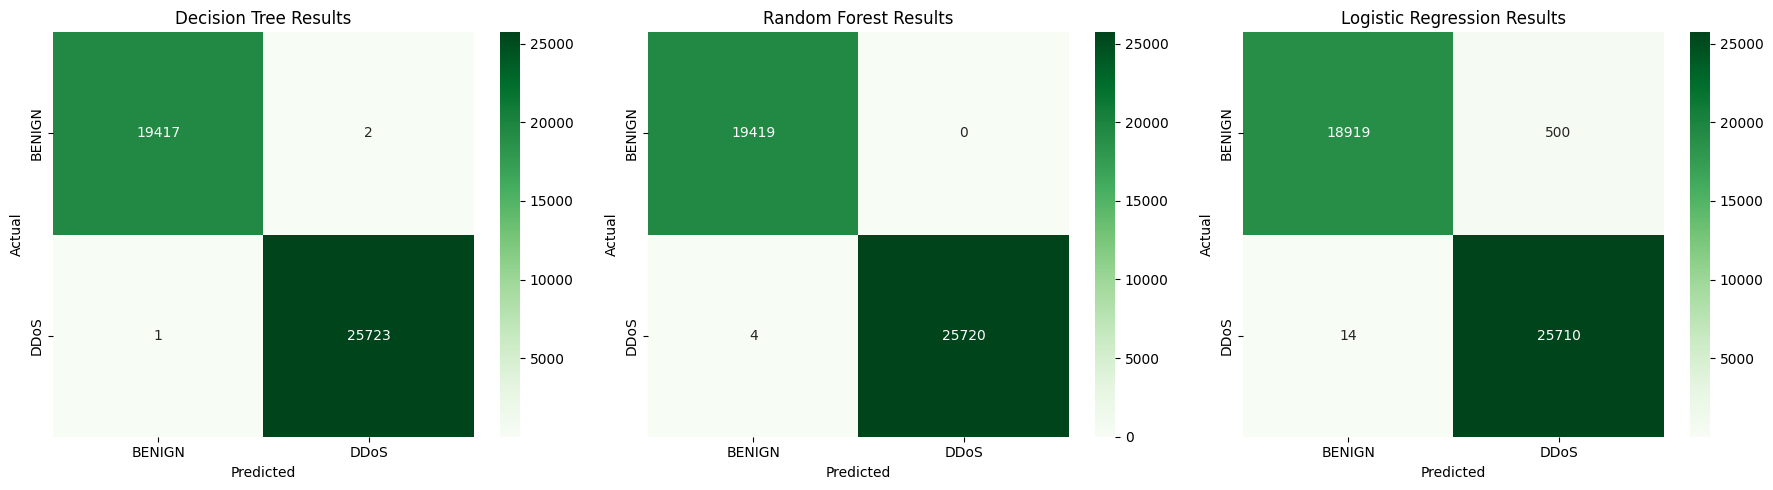


Random Forest Post-Test Accuracy: 0.9999113926854661

AI Models have been successfully trained and evaluated.


In [6]:
# --- STEP 3: DATA CLEANING, SMOTE, AND AI MODEL TRAINING ---
# This script builds your new AI system.
# Copy this into a NEW cell in Colab and run it.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# 1. CLEANING DATA
print("Phase 3: Preparing Data...")
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Drop non-numeric/identifier columns (Source IP, Flow ID, etc.)
# We only want 'behavioral' features for the AI
cols_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns] + ['Label'])
y = df['Label']

# 2. ENCODING & SCALING
le = LabelEncoder()
y = le.fit_transform(y)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. APPLY SMOTE (Fix Class Imbalance)
# This creates synthetic attack samples so the AI learns better.
print("Applying SMOTE (balancing dataset)...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 5. TRAINING MODELS
print("Training AI Models (This may take a few minutes)...")

# Model 1: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)
y_pred_dt = dt.predict(X_test)

# Model 2: Random Forest (The Mathematical Ensemble Model)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

# Model 3: Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)

# 6. RESULTS VISUALIZATION (Confusion Matrices)
print("\nGenerating Visual Results...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf), ('Logistic Regression', y_pred_lr)]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name} Results')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\nRandom Forest Post-Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nAI Models have been successfully trained and evaluated.")

Generating Final Comparison Report...

FINAL PERFORMANCE COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1-Score
      Decision Tree  0.999934   0.999934 0.999934  0.999934
      Random Forest  0.999911   0.999911 0.999911  0.999911
Logistic Regression  0.988614   0.988811 0.988614  0.988595


<Figure size 1400x700 with 0 Axes>

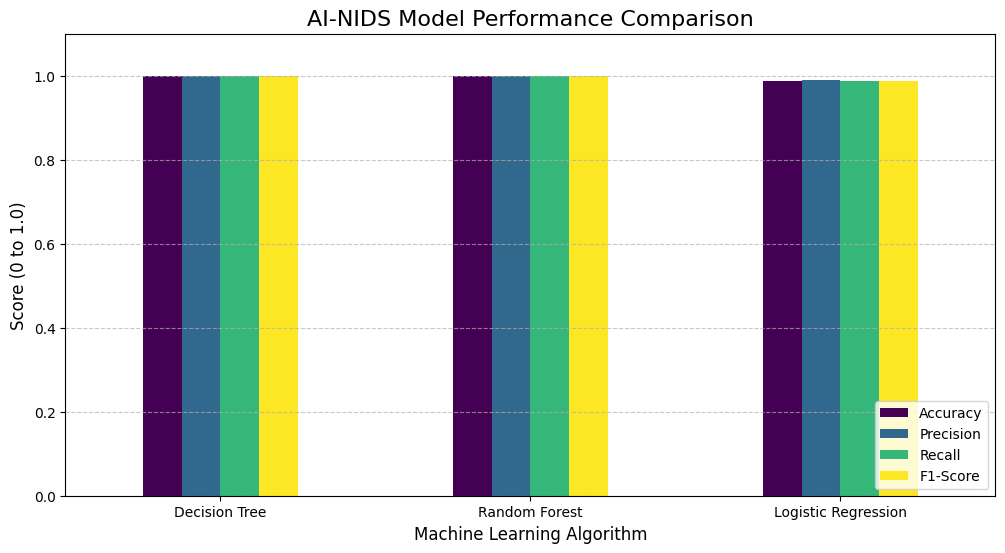


Final chart saved as 'model_comparison_chart.png'.
Congratulations! Your implementation is complete.


In [7]:
# --- STEP 4: FINAL MODEL COMPARISON & VISUALIZATION ---
# This script creates the professional comparison charts for your slides.
# Copy this into the FINAL cell in Colab and run it.

from sklearn.metrics import precision_score, recall_score, f1_score

print("Generating Final Comparison Report...")

# 1. Calculate all metrics for all models
# average='weighted' is used to account for the class distribution
results_data = {
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)],
    'Precision': [
        precision_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)],
    'Recall': [
        recall_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)],
    'F1-Score': [
        f1_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)]
}

# 2. Create the Summary Table
comparison_df = pd.DataFrame(results_data)
print("\n" + "="*50)
print("FINAL PERFORMANCE COMPARISON TABLE")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)

# 3. Create the Comparison Bar Chart
plt.figure(figsize=(14, 7))
comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='viridis')

plt.title('AI-NIDS Model Performance Comparison', fontsize=16)
plt.ylabel('Score (0 to 1.0)', fontsize=12)
plt.xlabel('Machine Learning Algorithm', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)  # Scale from 0 to 110% for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0))

# Save the figure for your report
plt.savefig('model_comparison_chart.png', dpi=300)
plt.show()

print("\nFinal chart saved as 'model_comparison_chart.png'.")
print("Congratulations! Your implementation is complete.")

In [9]:
# --- STEP 5: THE LIVE INTRUSION DETECTION SYSTEM (NIDS) INTERFACE ---
# This script turns your research into a working software "System".
# Copy this into a NEW cell at the very bottom of your Colab.

import joblib
import pandas as pd
import numpy as np
from google.colab import files
import io
import time

print("--- INITIALIZING AI-NIDS SYSTEM INTERFACE ---")

# 1. PERSISTENCE LAYER: Save the 'Brain'
# We save the Random Forest model, Scaler, and Label Encoder for deployment.
joblib.dump(rf, 'nids_best_model.pkl')
joblib.dump(scaler, 'nids_scaler.pkl')
joblib.dump(le, 'nids_label_encoder.pkl')
print("[SYSTEM] Model components saved as .pkl files.")

def security_scanner(input_data):
    """
    Inference Engine: Processes raw traffic and returns classification labels.
    """
    model = joblib.load('nids_best_model.pkl')
    scl = joblib.load('nids_scaler.pkl')
    enc = joblib.load('nids_label_encoder.pkl')

    # Pre-processing input for the model
    scaled_data = scl.transform(input_data)
    prediction = model.predict(scaled_data)
    return enc.inverse_transform(prediction)

def run_live_dashboard():
    print("\n" + "="*60)
    print("             AI-POWERED NIDS SECURITY DASHBOARD             ")
    print("="*60)
    print("[STATUS] System Online. Monitoring packet flows...")
    time.sleep(1)

    # Simulate a real-time monitor by pulling 5 random connections
    sample_traffic = X.sample(5)
    threat_decisions = security_scanner(sample_traffic)

    print("\n--- RECENT NETWORK ACTIVITY ---")
    for i, pred in enumerate(threat_decisions):
        timestamp = time.strftime('%H:%M:%S')
        if pred == 'BENIGN':
            print(f"[{timestamp}] Connection {i+1}: ✅ NORMAL  | Status: Access Granted")
        else:
            print(f"[{timestamp}] Connection {i+1}: ⚠️ {pred.upper()} DETECTED | Status: Blocked")

    print("\n" + "="*60)
    print("DEMO MODE: Upload a CSV for a System-Wide Network Scan")

    # 2. INTERACTIVE SCANNING: Trigger the Live Demo
    uploaded = files.upload()
    if uploaded:
        for name, data in uploaded.items():
            print(f"\n[SYSTEM] Analyzing {name}...")
            new_df = pd.read_csv(io.BytesIO(data))

            # --- ROBUST DATA CLEANING FOR UPLOADED FILE ---
            # Remove leading/trailing spaces from columns
            new_df.columns = new_df.columns.str.strip()

            # Replace Infinity with NaN and drop rows with NaN values
            new_df.replace([np.inf, -np.inf], np.nan, inplace=True)
            new_df.dropna(inplace=True)

            # Align columns: drop target labels and identifiers
            scan_X = new_df.drop(columns=['Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'], errors='ignore')

            if len(scan_X) == 0:
                print(f"[ERROR] No valid data found in {name} after cleaning.")
                continue

            start_time = time.time()
            results = security_scanner(scan_X)
            end_time = time.time()

            # Summary Report
            threats = sum(1 for r in results if r != 'BENIGN')
            print(f"\n--- SCAN SUMMARY ---")
            print(f"Total Flows Scanned: {len(results)}")
            print(f"Threats Identified: {threats}")
            print(f"Processing Time:    {end_time - start_time:.4f} seconds")
            print(f"Network Integrity:  {'SECURE' if threats == 0 else 'COMPROMISED'}")
            print("-" * 30)

# Run the complete system
run_live_dashboard()

--- INITIALIZING AI-NIDS SYSTEM INTERFACE ---
[SYSTEM] Model components saved as .pkl files.

             AI-POWERED NIDS SECURITY DASHBOARD             
[STATUS] System Online. Monitoring packet flows...

--- RECENT NETWORK ACTIVITY ---
[00:25:09] Connection 1: ✅ NORMAL  | Status: Access Granted
[00:25:09] Connection 2: ⚠️ DDOS DETECTED | Status: Blocked
[00:25:09] Connection 3: ⚠️ DDOS DETECTED | Status: Blocked
[00:25:09] Connection 4: ✅ NORMAL  | Status: Access Granted
[00:25:09] Connection 5: ⚠️ DDOS DETECTED | Status: Blocked

DEMO MODE: Upload a CSV for a System-Wide Network Scan


Saving Defense_Demo.csv to Defense_Demo (1).csv

[SYSTEM] Analyzing Defense_Demo (1).csv...

--- SCAN SUMMARY ---
Total Flows Scanned: 282
Threats Identified: 123
Processing Time:    0.0681 seconds
Network Integrity:  COMPROMISED
------------------------------
